# import Libraries

In [149]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
%matplotlib inline
from datetime import datetime 

#  Read Data

In [109]:
df=pd.read_csv("data/processed_data_all.csv")
site1=pd.read_csv("data/site1_Data.csv")
site2=pd.read_csv("data/site2_Data.csv")

In [110]:
df.head()

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,...,paymentRequired,requestedDeparture,userID,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation
0,0,5bc90cb9f9af8b0d7fe77cd2,2018-04-25 04:08:04,2018-04-25 06:20:10,2018-04-25 06:20:10,7.932,2_39_78_362_2018-04-25 11:08:04.400812,2,CA-496,2-39-78-362,...,unknown,NaN,unknown,2018-04-25 10:53:00,12.0,26.0,Cloudy,989.11,11.0,0.0
1,1,5bc90cb9f9af8b0d7fe77cd3,2018-04-25 06:45:10,2018-04-25 17:56:16,2018-04-25 09:44:15,10.013,2_39_95_27_2018-04-25 13:45:09.617470,2,CA-319,2-39-95-27,...,unknown,NaN,unknown,2018-04-25 13:53:00,12.0,20.0,Fog,989.44,7.0,0.0
2,2,5bc90cb9f9af8b0d7fe77cd4,2018-04-25 06:45:50,2018-04-25 16:04:45,2018-04-25 07:51:44,5.257,2_39_79_380_2018-04-25 13:45:49.962001,2,CA-489,2-39-79-380,...,unknown,NaN,unknown,2018-04-25 13:53:00,12.0,20.0,Fog,989.44,7.0,0.0
3,3,5bc90cb9f9af8b0d7fe77cd5,2018-04-25 07:37:06,2018-04-25 16:55:34,2018-04-25 09:05:22,5.177,2_39_79_379_2018-04-25 14:37:06.460772,2,CA-327,2-39-79-379,...,unknown,NaN,unknown,2018-04-25 14:53:00,12.0,26.0,Cloudy,990.10,6.0,0.0
4,4,5bc90cb9f9af8b0d7fe77cd6,2018-04-25 07:40:34,2018-04-25 16:03:12,2018-04-25 10:40:30,10.119,2_39_79_381_2018-04-25 14:40:33.638896,2,CA-490,2-39-79-381,...,unknown,NaN,unknown,2018-04-25 14:53:00,12.0,26.0,Cloudy,990.10,6.0,0.0


In [111]:
print(df.index)

RangeIndex(start=0, stop=66423, step=1)


In [112]:
df['time']=df['connectionTime']
df['time']=pd.to_datetime(df['time'])
df=df.set_index('time')

In [113]:
site1['time']=site1['connectionTime']
site1['time']=pd.to_datetime(site1['time'])
site1=site1.set_index('time')

In [114]:
site2['time']=site2['connectionTime']
site2['time']=pd.to_datetime(site2['time'])
site2=site2.set_index('time')

# Temporal Patterns and Seasonality

## During the day

### All sites

In [115]:
Three_years_hourly_counts=df.groupby(df.index.hour).size()
# total number of charges in the same time period (hour) across three years
Three_years_hourly_counts

time
0       149
1        86
2        72
3       128
4       446
5      2649
6      8329
7     11515
8      8167
9      6265
10     3827
11     3023
12     3684
13     3111
14     2617
15     2727
16     2474
17     1796
18     1730
19     1287
20      996
21      689
22      431
23      225
dtype: int64

In [116]:
number_of_days = len(set(df.index.date))
print(number_of_days)
hourly_avg = Three_years_hourly_counts/number_of_days
hourly_avg=hourly_avg.round().astype(int)

1125


In [117]:
# Round to the nearest integer 
hourly_counts= hourly_avg.reset_index()
hourly_counts.columns = ['Hour', 'Vehicle_charging_Count']
hourly_counts

,Hour,Vehicle_charging_Count
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
5,5,2
6,6,7
7,7,10
8,8,7
9,9,6


<BarContainer object of 24 artists>

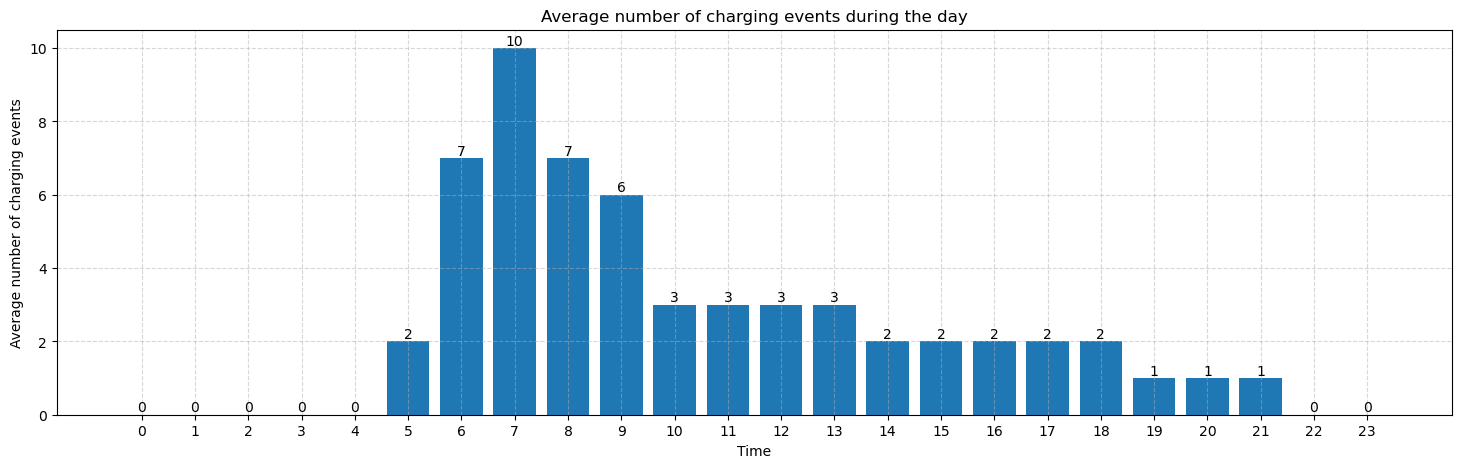

In [118]:
fig=plt.figure(figsize=(18,5))
x=hourly_counts['Hour']
y=hourly_counts['Vehicle_charging_Count']
plt.title('Average number of charging events during the day')
for (a,b) in zip(x,y):
    plt.text(x=a,y=b,s=b,ha='center',va='bottom')
plt.grid(ls="--",alpha=0.5)
plt.xticks(x)
plt.xlabel('Time')
plt.ylabel('Average number of charging events')
plt.bar(x,y)

This bar chart illustrates the average number of charging events during different hours of the day, showing distinct peaks and troughs. The peak period occurs between 5 AM and 9 AM, with the highest activity at 7 AM, likely driven by commuting needs and off-peak electricity rates. In contrast, charging demand is minimal during late-night hours (12 AM to 4 AM) and after 10 PM. During the day, from 10 AM to 6 PM, the number of charging events remains relatively steady at a lower level. 

### separating site1 and site2

In [119]:
Three_years_hourly_counts_site1=site1.groupby(site1.index.hour).size()
# total number of charges in the same time period (hour) across three years
Three_years_hourly_counts_site2=site2.groupby(site2.index.hour).size()

In [120]:
number_of_days_site1=len(set(site1.index.date))
print(number_of_days_site1)
hourly_avg_site1=Three_years_hourly_counts_site1/number_of_days_site1
hourly_avg_site1=hourly_avg_site1.round().astype(int)

951


In [121]:
number_of_days_site2=len(set(site2.index.date))
print(number_of_days_site2)
hourly_avg_site2=Three_years_hourly_counts_site2/number_of_days_site2
hourly_avg_site2=hourly_avg_site2.round().astype(int)

1084


In [122]:
Three_years_hourly_counts_site1= hourly_avg_site1.reset_index()
Three_years_hourly_counts_site2= hourly_avg_site2.reset_index()
Three_years_hourly_counts_site1.columns = ['Hour', 'Vehicle_charging_Count_site1']
Three_years_hourly_counts_site2.columns = ['Hour', 'Vehicle_charging_Count_site2']


In [123]:
print(Three_years_hourly_counts_site1)

    Hour  Vehicle_charging_Count_site1
0      0                             0
1      1                             0
2      2                             0
3      3                             0
4      4                             0
5      5                             3
6      6                             8
7      7                            10
8      8                             3
9      9                             2
10    10                             1
11    11                             2
12    12                             2
13    13                             1
14    14                             1
15    15                             2
16    16                             1
17    17                             0
18    18                             0
19    19                             0
20    20                             0
21    21                             0
22    22                             0
23    23                             0


In [124]:
print(Three_years_hourly_counts_site2)

    Hour  Vehicle_charging_Count_site2
0      0                             0
1      1                             0
2      2                             0
3      3                             0
4      4                             0
5      5                             0
6      6                             1
7      7                             2
8      8                             5
9      9                             4
10    10                             3
11    11                             1
12    12                             2
13    13                             2
14    14                             1
15    15                             1
16    16                             1
17    17                             1
18    18                             1
19    19                             1
20    20                             1
21    21                             1
22    22                             0
23    23                             0


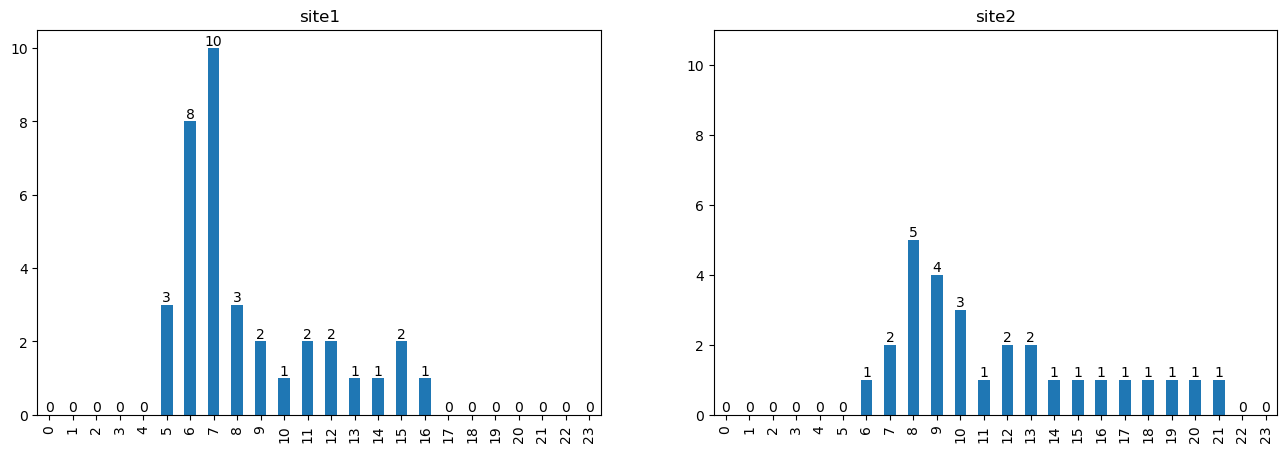

In [125]:
fig,ax=plt.subplots(1,2,figsize=(16,5))
y_min,y_max=0,11
site1_bars=Three_years_hourly_counts_site1['Vehicle_charging_Count_site1'].plot(kind='bar',ax=ax[0],title='site1')
for bar in site1_bars.patches:
    ax[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),f'{int(bar.get_height())}',ha='center', va='bottom') 
site2_bars=Three_years_hourly_counts_site2['Vehicle_charging_Count_site2'].plot(kind='bar',ax=ax[1],title='site2')
ax[1].set_ylim(y_min, y_max)
for bar in site2_bars.patches:
    ax[1].text(bar.get_x() + bar.get_width()/2,bar.get_height(),f'{int(bar.get_height())}',ha='center', va='bottom') 

## During the weeek

### all data

In [126]:
df.index.dayofweek

Index([2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       ...
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype='int32', name='time', length=66423)

In [127]:
# the number of weekdays
unique_dates = df.index.normalize().unique()
Monday_count =(pd.to_datetime(unique_dates).dayofweek == 0).sum()
print("Number of Mondays:",Monday_count)
Tuesday_count =(pd.to_datetime(unique_dates).dayofweek == 1).sum()
print("Number of Tuesdays:",Tuesday_count)
Wednesday_count =(pd.to_datetime(unique_dates).dayofweek == 2).sum()
print("Number of Wednesdays:",Wednesday_count)
Thursday_count =(pd.to_datetime(unique_dates).dayofweek == 3).sum()
print("Number of Thursdays:",Thursday_count)
Friday_count =(pd.to_datetime(unique_dates).dayofweek == 4).sum()
print("Number of Fridays:",Friday_count)
Saturday_count =(pd.to_datetime(unique_dates).dayofweek == 5).sum()
print("Number of Saturdays:",Saturday_count)
Sunday_count =(pd.to_datetime(unique_dates).dayofweek == 6).sum()
print("Number of Sundays:",Sunday_count)

Number of Mondays: 161
Number of Tuesdays: 160
Number of Wednesdays: 161
Number of Thursdays: 162
Number of Fridays: 162
Number of Saturdays: 160
Number of Sundays: 159


In [128]:
day_counts=pd.Series([Monday_count, Tuesday_count, Wednesday_count, Thursday_count, Friday_count, Saturday_count, Sunday_count],
                     index=['Mon','Tues','Wed','Thurs','Fri','Sat','Sun'])
print(day_counts)

Mon      161
Tues     160
Wed      161
Thurs    162
Fri      162
Sat      160
Sun      159
dtype: int32


In [129]:
weekday=df.groupby(df.index.dayofweek).size()
weekday.index=['Mon','Tues','Wed','Thurs','Fri','Sat','Sun']
weekday

Mon      12063
Tues     12963
Wed      12765
Thurs    12499
Fri      10415
Sat       3008
Sun       2710
dtype: int64

In [130]:
average_numbe_of_charging=weekday/day_counts
average_numbe_of_charging=average_numbe_of_charging.round().astype(int)
print(average_numbe_of_charging)

Mon      75
Tues     81
Wed      79
Thurs    77
Fri      64
Sat      19
Sun      17
dtype: int32


In [131]:
Day_counts= average_numbe_of_charging.reset_index()
Day_counts.columns = ['Weekday', 'Vehicle_charging_Counts']
Day_counts

,Weekday,Vehicle_charging_Counts
0,Mon,75
1,Tues,81
2,Wed,79
3,Thurs,77
4,Fri,64
5,Sat,19
6,Sun,17


<BarContainer object of 7 artists>

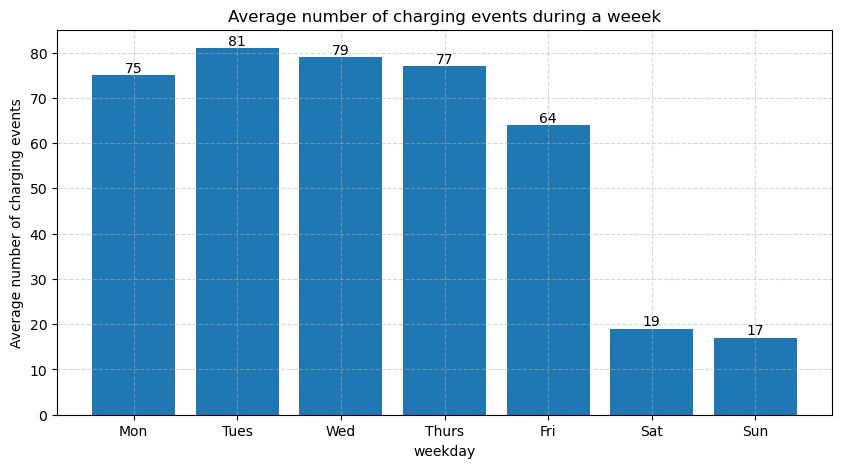

In [132]:
fig=plt.figure(figsize=(10,5))
x=Day_counts['Weekday']
y=Day_counts['Vehicle_charging_Counts']
plt.title('Average number of charging events during a weeek')
for (a,b) in zip(x,y):
    plt.text(x=a,y=b,s=b,ha='center',va='bottom')
plt.grid(ls="--",alpha=0.5)
plt.xticks(ticks=range(len(x)), labels=x)  
plt.xlabel('weekday')
plt.ylabel('Average number of charging events')
plt.bar(x,y)

This bar chart shows the average number of charging events during the week, with significantly higher activity on weekdays compared to weekends. The peak occurs on Tuesday (81), followed closely by Wednesday (79) and Thursday (77), indicating that charging demand is driven by weekday commuting and regular travel. In contrast, charging activity drops sharply on Saturday (19) and Sunday (17), reflecting reduced vehicle usage on weekends.

### seperating site1 and site 2

In [133]:
def analyze_week_charging(df):
    df.index.dayofweek
    # the number of weekdays
    unique_dates = df.index.normalize().unique()
    Monday_count =(pd.to_datetime(unique_dates).dayofweek == 0).sum()
    print("Number of Mondays:",Monday_count)
    Tuesday_count =(pd.to_datetime(unique_dates).dayofweek == 1).sum()
    print("Number of Tuesdays:",Tuesday_count)
    Wednesday_count =(pd.to_datetime(unique_dates).dayofweek == 2).sum()
    print("Number of Wednesdays:",Wednesday_count)
    Thursday_count =(pd.to_datetime(unique_dates).dayofweek == 3).sum()
    print("Number of Thursdays:",Thursday_count)
    Friday_count =(pd.to_datetime(unique_dates).dayofweek == 4).sum()
    print("Number of Fridays:",Friday_count)
    Saturday_count =(pd.to_datetime(unique_dates).dayofweek == 5).sum()
    print("Number of Saturdays:",Saturday_count)
    Sunday_count =(pd.to_datetime(unique_dates).dayofweek == 6).sum()
    print("Number of Sundays:",Sunday_count)
    day_counts=pd.Series([Monday_count, Tuesday_count, Wednesday_count, Thursday_count, Friday_count, Saturday_count, Sunday_count],
                     index=['Mon','Tues','Wed','Thurs','Fri','Sat','Sun'])
    print(day_counts)
    average_numbe_of_charging=weekday/day_counts
    average_numbe_of_charging=average_numbe_of_charging.round().astype(int)
    Day_counts= average_numbe_of_charging.reset_index()
    Day_counts.columns = ['Weekday', 'Vehicle_charging_Counts']
    Day_counts
    fig=plt.figure(figsize=(10,5))
    x=Day_counts['Weekday']
    y=Day_counts['Vehicle_charging_Counts']
    plt.title('Average number of charging events during a weeek')
    for (a,b) in zip(x,y):
        plt.text(x=a,y=b,s=b,ha='center',va='bottom')
        plt.grid(ls="--",alpha=0.5)
        plt.xticks(ticks=range(len(x)), labels=x)  
        plt.xlabel('weekday')
        plt.ylabel('Average number of charging events')
        plt.bar(x,y)


Number of Mondays: 140
Number of Tuesdays: 139
Number of Wednesdays: 140
Number of Thursdays: 141
Number of Fridays: 141
Number of Saturdays: 127
Number of Sundays: 123
Mon      140
Tues     139
Wed      140
Thurs    141
Fri      141
Sat      127
Sun      123
dtype: int32


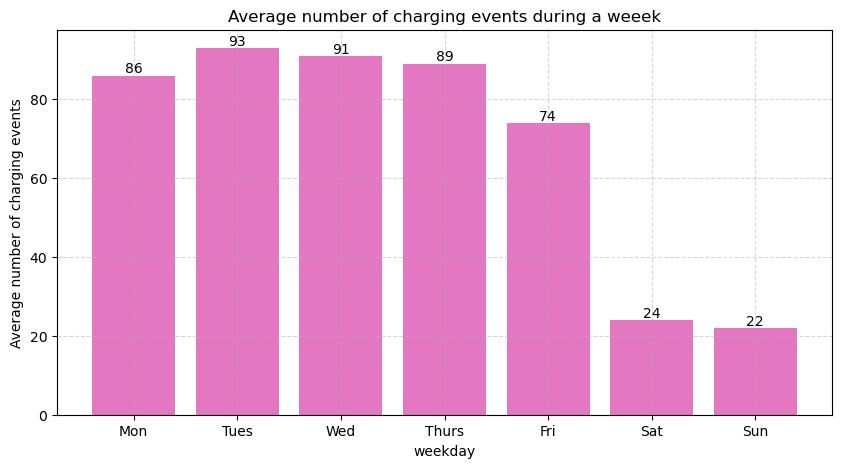

In [134]:
analyze_week_charging(site1)

Number of Mondays: 156
Number of Tuesdays: 154
Number of Wednesdays: 154
Number of Thursdays: 153
Number of Fridays: 153
Number of Saturdays: 157
Number of Sundays: 157
Mon      156
Tues     154
Wed      154
Thurs    153
Fri      153
Sat      157
Sun      157
dtype: int32


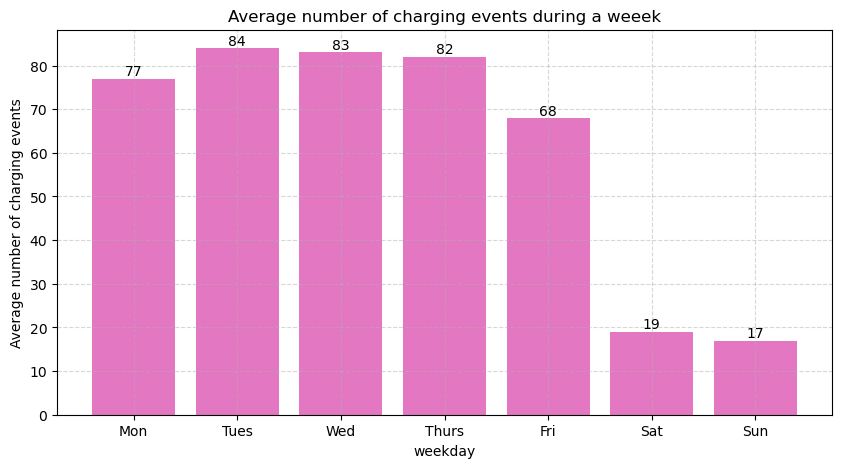

In [135]:
analyze_week_charging(site2)


### Charging patterns during a weekday and a weekend

In [136]:
week=np.where(df.index.weekday<5,'weekday','weekend')
charging_events_per_hour=df.groupby([week,df.index.hour]).size()
print(charging_events_per_hour)

         time
weekday  0          92
         1          55
         2          56
         3         116
         4         428
         5        2592
         6        8215
         7       11221
         8        7843
         9        5818
         10       3299
         11       2578
         12       3200
         13       2678
         14       2214
         15       2360
         16       2074
         17       1477
         18       1464
         19       1065
         20        815
         21        551
         22        332
         23        162
weekend  0          57
         1          31
         2          16
         3          12
         4          18
         5          57
         6         114
         7         294
         8         324
         9         447
         10        528
         11        445
         12        484
         13        433
         14        403
         15        367
         16        400
         17        319
         18        2

In [137]:
weekday_charging_events_per_hour=charging_events_per_hour['weekday']/(162*5)
weekday_charging_events_per_hour=weekday_charging_events_per_hour.round().astype(int)
weekend_charging_events_per_hour=charging_events_per_hour['weekend']/(160*2)
weekend_charging_events_per_hour=weekend_charging_events_per_hour.round().astype(int)
print(weekday_charging_events_per_hour)

time
0      0
1      0
2      0
3      0
4      1
5      3
6     10
7     14
8     10
9      7
10     4
11     3
12     4
13     3
14     3
15     3
16     3
17     2
18     2
19     1
20     1
21     1
22     0
23     0
dtype: int32


In [138]:
print(weekend_charging_events_per_hour)

time
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     1
8     1
9     1
10    2
11    1
12    2
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    1
21    0
22    0
23    0
dtype: int32


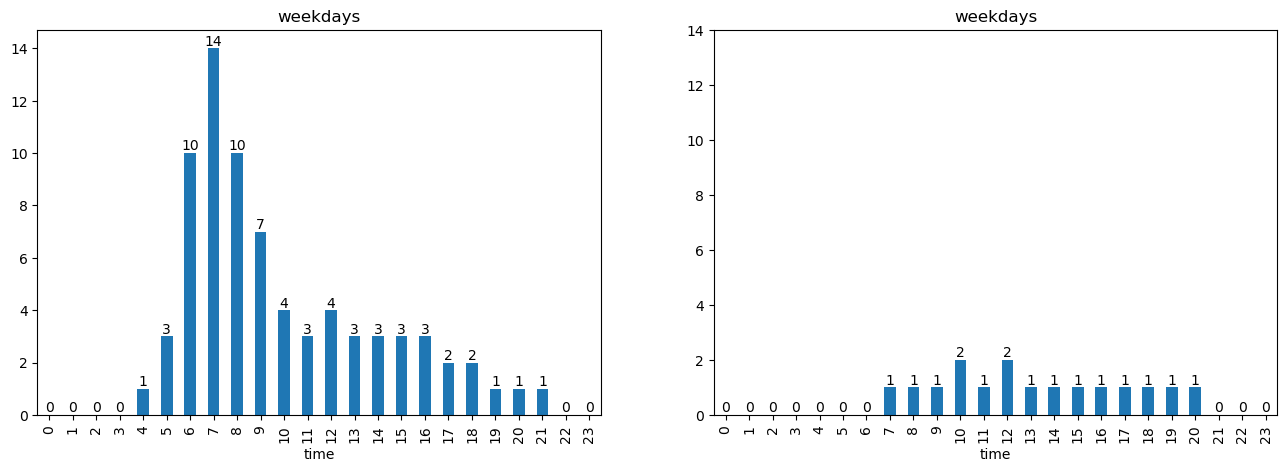

In [139]:
fig,ax=plt.subplots(1,2,figsize=(16,5))
y_min,y_max=0,14
weekday_bars=weekday_charging_events_per_hour.plot(kind='bar',ax=ax[0],title='weekdays')
for bar in weekday_bars.patches:
    ax[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),f'{int(bar.get_height())}',ha='center', va='bottom') 
weekend_bars=weekend_charging_events_per_hour.plot(kind='bar',ax=ax[1],title='weekdays')
ax[1].set_ylim(y_min, y_max)
for bar in weekend_bars.patches:
    ax[1].text(bar.get_x() + bar.get_width()/2,bar.get_height(),f'{int(bar.get_height())}',ha='center', va='bottom') 

## between the seasons

In [140]:
def get_season(month):
    if month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    elif month in [9,10,11]:
        return "Autumn"
    else:
        return "Winter"

In [141]:
df['month']=df.index.month

In [142]:
df['season']=df['month'].apply(get_season)
df['season']

time
2018-04-25 04:08:04    Spring
2018-04-25 06:45:10    Spring
2018-04-25 06:45:50    Spring
2018-04-25 07:37:06    Spring
2018-04-25 07:40:34    Spring
                        ...  
2021-09-13 15:33:07    Autumn
2021-09-13 16:11:12    Autumn
2021-09-13 18:08:16    Autumn
2021-09-13 18:52:37    Autumn
2021-09-13 22:43:39    Autumn
Name: season, Length: 66423, dtype: object

In [143]:
number_in_season=df['season'].value_counts()
number_in_season

season
Summer    19586
Autumn    17614
Winter    15065
Spring    14158
Name: count, dtype: int64

In [144]:
unique_season=df['season'].loc[df['season']!=df['season'].shift(1)]
season_counts=unique_season.value_counts()
print(season_counts)

season
Spring    4
Summer    4
Autumn    4
Winter    3
Name: count, dtype: int64


In [145]:
average_number_in_different_season=number_in_season/season_counts
average_number_in_different_season=average_number_in_different_season.astype(int)


In [146]:
average_number_in_different_season= average_number_in_different_season.reset_index()
average_number_in_different_season.columns = ['season', 'Vehicle_charging_Counts']
average_number_in_different_season

,season,Vehicle_charging_Counts
0,Autumn,4403
1,Spring,3539
2,Summer,4896
3,Winter,5021


<BarContainer object of 4 artists>

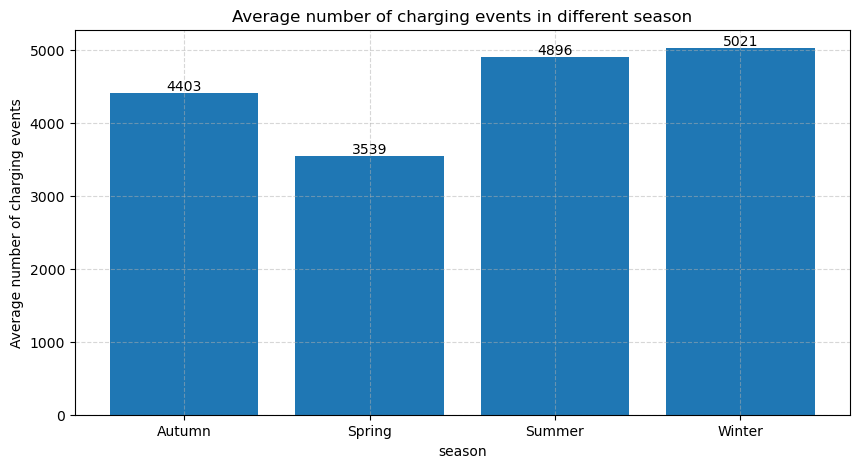

In [147]:
fig=plt.figure(figsize=(10,5))
x=average_number_in_different_season['season']
y=average_number_in_different_season['Vehicle_charging_Counts']
plt.title('Average number of charging events in different season')
for (a,b) in zip(x,y):
    plt.text(x=a,y=b,s=b,ha='center',va='bottom')
plt.grid(ls="--",alpha=0.5)
plt.xticks(ticks=range(len(x)), labels=x)  
plt.xlabel('season')
plt.ylabel('Average number of charging events')
plt.bar(x,y)

This chart shows the average number of charging events across different seasons, with the highest demand in winter (5021) and summer (4896), likely due to colder weather affecting battery range in winter and increased air conditioning use in summer. Autumn (4403) shows moderate demand, while spring (3539) has the lowest, possibly due to stable battery performance in mild weather.

### separate site1 and site 2

In [150]:
def get_season(month):
    if month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    elif month in [9,10,11]:
        return "Autumn"
    else:
        return "Winter"

In [151]:
def analyze_season_charging(df):
    df['month']=df.index.month
    df['season']=df['month'].apply(get_season)
    number_in_season=df['season'].value_counts()
    unique_season=df['season'].loc[df['season']!=df['season'].shift(1)]
    season_counts=unique_season.value_counts()
    average_number_in_different_season=number_in_season/season_counts
    average_number_in_different_season=average_number_in_different_season.astype(int)
    average_number_in_different_season= average_number_in_different_season.reset_index()
    average_number_in_different_season.columns = ['season', 'Vehicle_charging_Counts']
    fig=plt.figure(figsize=(10,5))
    x=average_number_in_different_season['season']
    y=average_number_in_different_season['Vehicle_charging_Counts']
    plt.title('Average number of charging events in different season')
    for (a,b) in zip(x,y):
        plt.text(x=a,y=b,s=b,ha='center',va='bottom')
    plt.grid(ls="--",alpha=0.5)
    plt.xticks(ticks=range(len(x)), labels=x)  
    plt.xlabel('season')
    plt.ylabel('Average number of charging events')
    plt.bar(x,y)

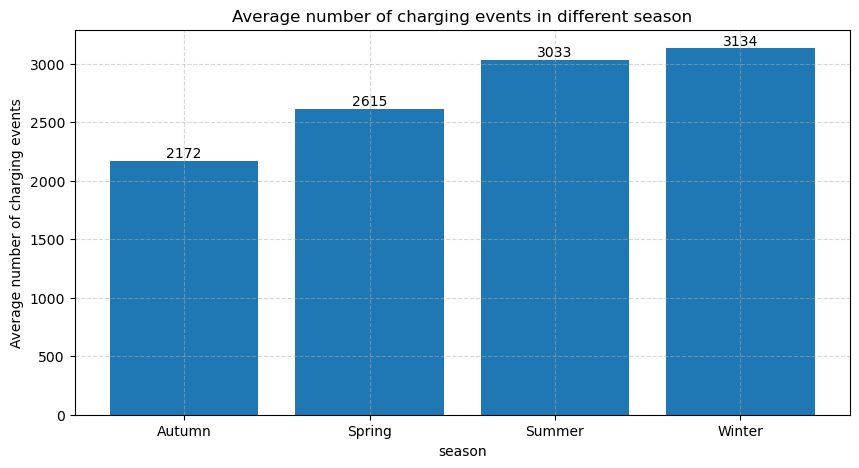

In [152]:
analyze_season_charging(site1)

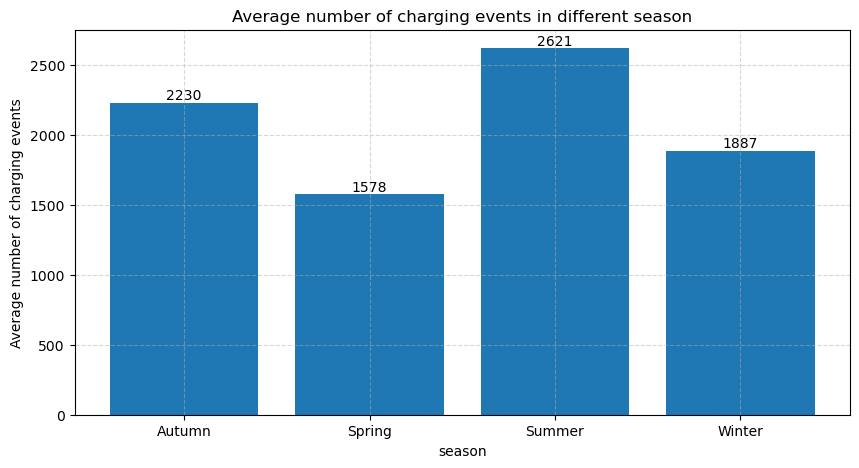

In [153]:
analyze_season_charging(site2)

site 1:private
###### Site1 exhibits typical characteristics of a private site (e.g., a company). Charging activities are primarily concentrated during weekday morning peak hours (6-8 AM), with the highest demand observed at 7 and 8 AM. On weekdays, Tuesday to Thursday show the highest number of charging events, while weekend usage is significantly lower, reflecting a fixed employee usage pattern. Seasonally, charging demand increases notably in summer and winter, likely due to higher energy needs for heating and cooling, while spring and autumn demand is relatively lower, reflecting seasonal variations in commuting energy consumption. Overall, Site1’s charging behavior is focused and regular, aligning with the commuting patterns of company employees on workdays.
site 2:school
###### Site2 exhibits characteristics of a public site (e.g., a university) with diverse user groups, including students, faculty, staff, and visitors. Charging demand is more evenly distributed throughout the day, with a small peak at 7-8 AM, scattered usage from 10 AM to the afternoon, and occasional activity from 5-10 PM. Seasonally, demand is highest in summer (2621 events), followed by autumn (2230), while winter (1887) and spring (1578) see lower activity, likely reflecting seasonal behavior patterns and campus activity levels. Weekdays show relatively stable usage (77-84 events per day), while weekend demand is lower but less variable compared to Site1. The overall pattern indicates a steady and diverse charging demand that aligns with the varying schedules and needs of a university’s mixed user base.

# draft

NameError: name 'daily_counts' is not defined

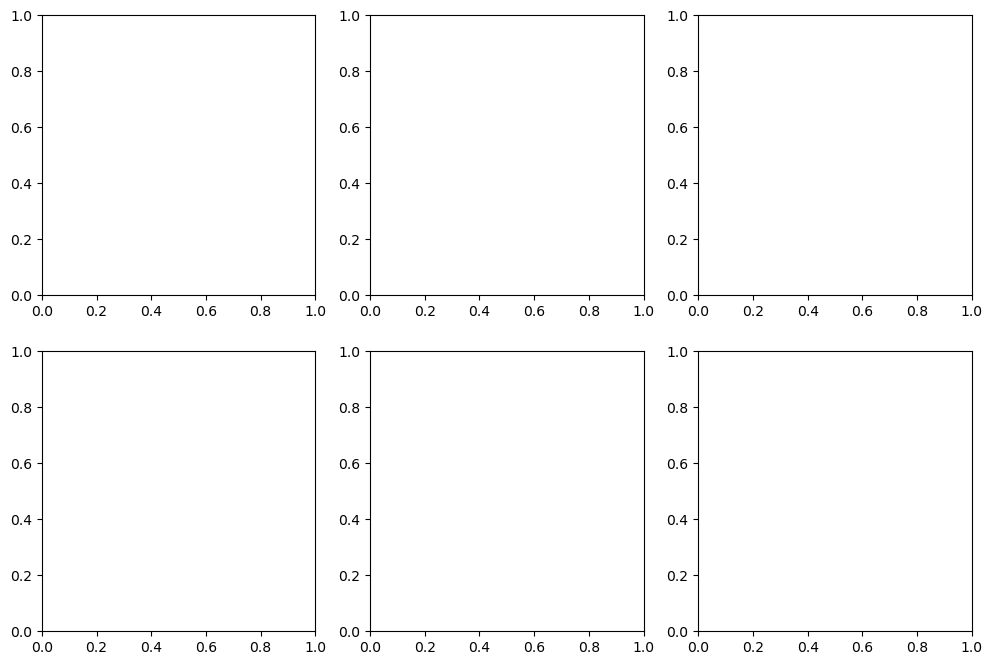

In [36]:
fig,axes = plt.subplots (2,3,figsize=(12,8))
daily_counts['2020-7'].plot(ax=axes[0, 0])
axes[0, 0].set_title('July 2020')
axes[0, 0].set_ylabel('Events')
daily_counts['2020-8'].plot(ax=axes[0, 1])
axes[0, 1].set_title('August 2020')
axes[0, 1].set_ylabel('Events')
daily_counts['2020-9'].plot(ax=axes[0, 2])
axes[0, 2].set_title('September 2020')
axes[0, 2].set_ylabel('Events')
daily_counts['2020-10'].plot(ax=axes[1,0])
axes[1,0].set_title('October 2020')
axes[1,0].set_ylabel('Events')
daily_counts['2020-11'].plot(ax=axes[1,1])
axes[1,1].set_title('November 2020')
axes[1,1].set_ylabel('Events')
daily_counts['2020-12'].plot(ax=axes[1, 2])
axes[1,2].set_title('December 2020')
axes[1,2].set_ylabel('Events')

